In [1]:
import os, time
import chipwhisperer as cw

BITFILE = r'C:\Users\sbista\ChipWhisperer\chipwhisperer\firmware\fpgas\aes\vivado\cw305_aes.runs\impl_100t\cw305_top.bit'

assert os.path.isfile(BITFILE), f"Bitstream not found: {BITFILE}"

# 1) Connect to the capture board (CWLite)
scope = cw.scope()
scope.default_setup()


# 3) Connect and Program the FPGA
print("Programming CW305 FPGA with:", BITFILE)
target = cw.target(scope, cw.targets.CW305, bsfile=BITFILE, force=True)


scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 2818045                   to 17139249                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 11359542                  to 29538459                 
scope.clock.adc_rate                     changed from 11359542.0                to 29538459.0               
scope.clock.freq_ct

(ChipWhisperer Target WARNING|File CW305.py:591) Using default Verilog defines (C:\Users\sbista\ChipWhisperer\chipwhisperer\software\chipwhisperer/hardware/firmware/cw305/cw305_aes_defines.v); if this is not what you want, provide them via the defines_files argument


In [2]:
from Crypto.Cipher import AES

# Known NIST AES-128 test vector
KEY = bytes.fromhex("2b7e151628aed2a6abf7158809cf4f3c")
PT  = bytes.fromhex("5c692f9103b2302914d7e555e4dcee49")

# Expected ciphertext
expected_ct = AES.new(KEY, AES.MODE_ECB).encrypt(PT)
print("Expected CT:", expected_ct.hex())


Expected CT: 06f36a65e8a99ff8907b2e5e5ddd77de


In [3]:
# Write KEY
target.fpga_write(target.REG_CRYPT_KEY, KEY)

# Write PLAINTEXT
target.fpga_write(target.REG_CRYPT_TEXTIN, PT)

# Trigger encryption
target.fpga_write(target.REG_CRYPT_GO, b"\x01")

# Small delay (AES is fast but be safe)
time.sleep(0.01)

In [4]:
# Read ciphertext
ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))
print("FPGA CT   :", ct.hex())
print("MATCH?    :", ct == expected_ct)

FPGA CT   : 06f36a65e8a99ff8907b2e5e5ddd77de
MATCH?    : True


In [5]:
for i in range(10):
    target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")
    time.sleep(0.002)
    ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))
    print(i, ct.hex())

0 06f36a65e8a99ff8907b2e5e5ddd77de
1 06f36a65e8a99ff8907b2e5e5ddd77de
2 06f36a65e8a99ff8907b2e5e5ddd77de
3 06f36a65e8a99ff8907b2e5e5ddd77de
4 06f36a65e8a99ff8907b2e5e5ddd77de
5 06f36a65e8a99ff8907b2e5e5ddd77de
6 06f36a65e8a99ff8907b2e5e5ddd77de
7 06f36a65e8a99ff8907b2e5e5ddd77de
8 06f36a65e8a99ff8907b2e5e5ddd77de
9 06f36a65e8a99ff8907b2e5e5ddd77de


In [6]:
scope.default_setup()
scope.adc.samples = 3000         # number of samples per trace
scope.adc.offset  = 0
scope.adc.presamples = 200       # capture a bit before trigger
scope.adc.decimate = 1
scope.adc.timeout = 2
# ---- Gain (CWLite safe range: 20–45 dB) ----
scope.gain.db = 35
# ---- Trigger: FPGA asserts trigger at AES start ----
scope.trigger.triggers = "tio4"
#scope.trigger.module = "basic"

print(scope)

cwlite Device
sn         = 50203220594a48303130313230313035
fw_version = 
    major = 0
    minor = 65
    debug = 0
gain = 
    mode = high
    gain = 46
    db   = 35.1484375
adc = 
    state          = False
    basic_mode     = rising_edge
    timeout        = 2
    offset         = 0
    presamples     = 200
    samples        = 3000
    decimate       = 1
    trig_count     = 17139824
    fifo_fill_mode = normal
clock = 
    adc_src       = clkgen_x4
    adc_phase     = 0
    adc_freq      = 29538459
    adc_rate      = 29538459.0
    adc_locked    = True
    freq_ctr      = 0
    freq_ctr_src  = extclk
    clkgen_src    = system
    extclk_freq   = 10000000
    clkgen_mul    = 2
    clkgen_div    = 26
    clkgen_freq   = 7384615.384615385
    clkgen_locked = True
trigger = 
    triggers = tio4
    module   = basic
io = 
    tio1         = serial_rx
    tio2         = serial_tx
    tio3         = high_z
    tio4         = high_z
    pdid         = high_z
    pdic         = high_z

In [7]:
scope.arm()
target.fpga_write(target.REG_CRYPT_TEXTIN, b"\x00"*16)
target.fpga_write(target.REG_CRYPT_GO, b"\x01")

if scope.capture():
    print("❌ Trigger not seen")
else:
    print("✅ Trigger OK")

✅ Trigger OK


In [8]:
#KEY = bytes.fromhex("000102030405060708090a0b0c0d0e0f")
#PT  = bytes.fromhex("00112233445566778899aabbccddeeff")
KEY = bytes.fromhex("2b7e151628aed2a6abf7158809cf4f3c")
PT  = bytes.fromhex("5c692f9103b2302914d7e555e4dcee49")
# Load key once
target.fpga_write(target.REG_CRYPT_KEY, KEY)

# Arm scope
scope.arm()

# Launch AES
target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
target.fpga_write(target.REG_CRYPT_GO, b"\x01")

# Capture
if scope.capture():
    raise RuntimeError("Timeout during capture")

# Read trace
trace = scope.get_last_trace()
print("Trace length:", len(trace))


Trace length: 3000


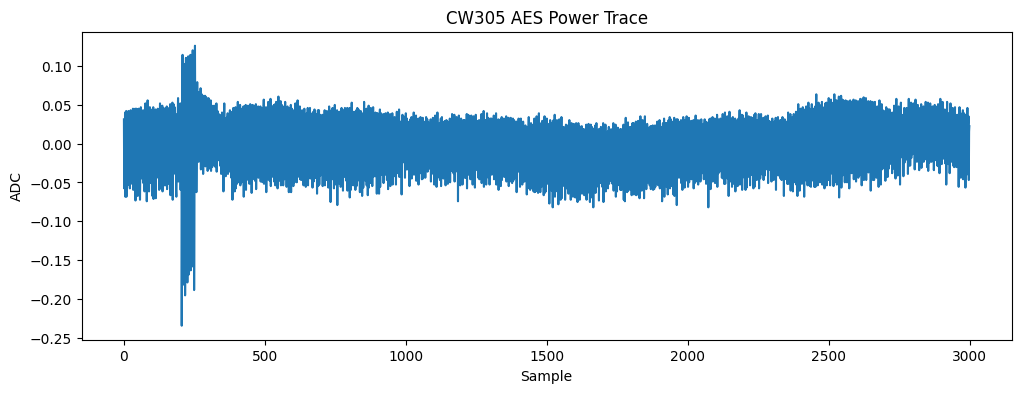

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(trace)
plt.title("CW305 AES Power Trace")
plt.xlabel("Sample")
plt.ylabel("ADC")
plt.show()

In [10]:
import numpy as np
import time
N = 10000
traces = []
pts = []
cts = []

for i in range(N):
    pt = np.random.bytes(16)

    scope.arm()
    target.fpga_write(target.REG_CRYPT_TEXTIN, pt)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")

    if scope.capture():
        print("Timeout at", i)
        continue

    trace = scope.get_last_trace()
    ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

    traces.append(trace)
    pts.append(pt)
    cts.append(ct)

print("Captured:", len(traces), "traces")


Captured: 10000 traces


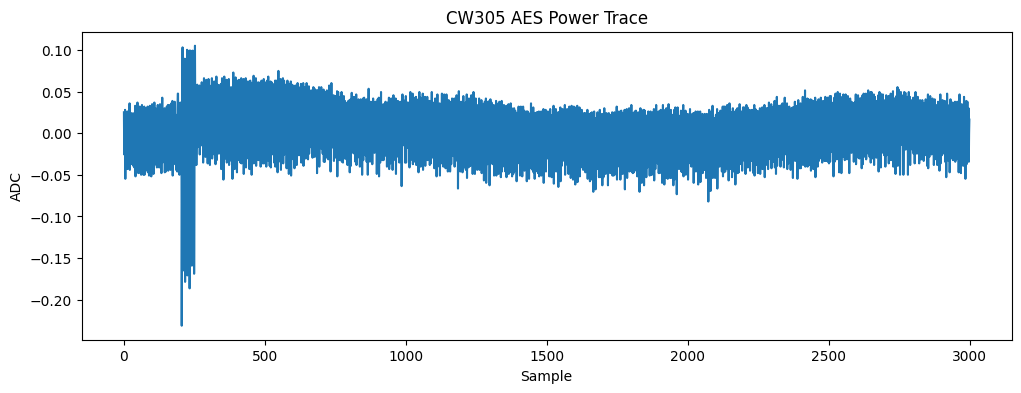

In [11]:
plt.figure(figsize=(12,4))
plt.plot(trace)
plt.title("CW305 AES Power Trace")
plt.xlabel("Sample")
plt.ylabel("ADC")
plt.show()

Traces shape: (200, 3000)
Shift stats: min/mean/max = 0 0.0 0
Corr stats : min/mean/max = 0.78009945 0.9114677 1.0


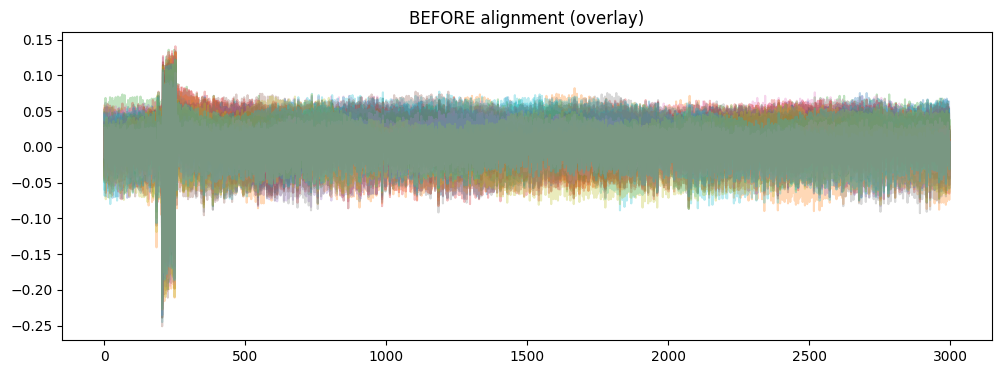

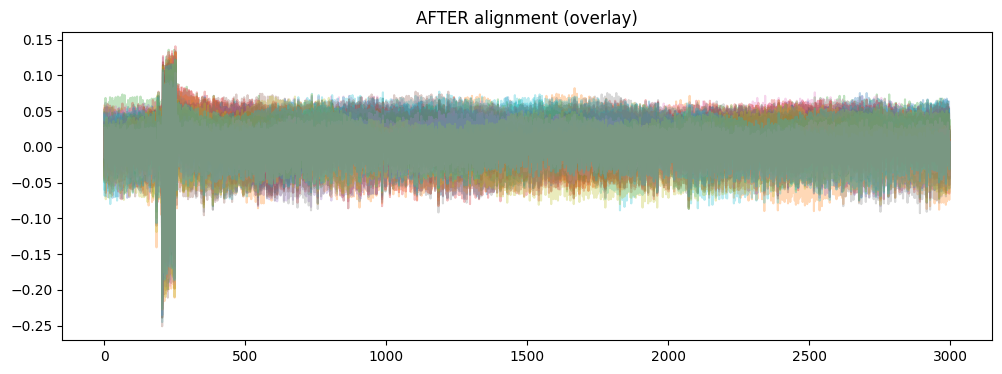

Shift stats: 0 0.0 0


In [13]:
import numpy as np
import time

N = 200
NSAMPLES = 3000

scope.adc.samples = NSAMPLES
scope.adc.presamples = 200
scope.gain.db = 35

KEY = bytes.fromhex("2b7e151628aed2a6abf7158809cf4f3c")
target.fpga_write(target.REG_CRYPT_KEY, KEY)

traces = []
pts = []
cts = []

for i in range(N):
    pt = np.random.bytes(16)

    scope.arm()
    target.fpga_write(target.REG_CRYPT_TEXTIN, pt)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")

    if scope.capture():
        print("Timeout at", i)
        continue

    tr = np.array(scope.get_last_trace(), dtype=np.float32)
    ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

    traces.append(tr)
    pts.append(pt)
    cts.append(ct)

traces = np.vstack(traces)
print("Traces shape:", traces.shape)

import numpy as np

def best_shift_by_corr(x, ref, max_shift=80):
    """
    Find shift s in [-max_shift, +max_shift] maximizing correlation with ref.
    Positive s means x is shifted RIGHT (delayed) relative to ref.
    """
    best_s = 0
    best_c = -1e18

    # normalize once (helps stability)
    ref0 = ref - ref.mean()
    ref0_norm = np.linalg.norm(ref0) + 1e-12

    for s in range(-max_shift, max_shift + 1):
        if s < 0:
            xs = x[-s:]          # drop first -s
            rs = ref[:len(xs)]
        elif s > 0:
            xs = x[:-s]          # drop last s
            rs = ref[s:]
        else:
            xs = x
            rs = ref

        xs0 = xs - xs.mean()
        denom = (np.linalg.norm(xs0) + 1e-12) * ref0_norm
        c = float(np.dot(xs0, rs - rs.mean()) / denom)

        if c > best_c:
            best_c = c
            best_s = s

    return best_s, best_c


def apply_shift(x, s):
    """Shift x by s samples, padding with edge values to keep length."""
    if s == 0:
        return x
    y = np.empty_like(x)
    if s > 0:
        # shift right
        y[:s] = x[0]
        y[s:] = x[:-s]
    else:
        # shift left
        s = -s
        y[-s:] = x[-1]
        y[:-s] = x[s:]
    return y


def align_traces(traces, max_shift=80, ref_index=0):
    ref = traces[ref_index]
    aligned = np.empty_like(traces)
    shifts = np.zeros(traces.shape[0], dtype=int)
    cors = np.zeros(traces.shape[0], dtype=np.float32)

    aligned[ref_index] = ref

    for i in range(traces.shape[0]):
        if i == ref_index:
            cors[i] = 1.0
            continue
        s, c = best_shift_by_corr(traces[i], ref, max_shift=max_shift)
        shifts[i] = s
        cors[i] = c
        aligned[i] = apply_shift(traces[i], s)

    return aligned, shifts, cors

aligned_traces, shifts, cors = align_traces(traces, max_shift=80, ref_index=0)

print("Shift stats: min/mean/max =", shifts.min(), shifts.mean(), shifts.max())
print("Corr stats : min/mean/max =", cors.min(), cors.mean(), cors.max())


import matplotlib.pyplot as plt

idx = np.random.choice(traces.shape[0], size=min(20, traces.shape[0]), replace=False)

plt.figure(figsize=(12,4))
for i in idx:
    plt.plot(traces[i], alpha=0.3)
plt.title("BEFORE alignment (overlay)")
plt.show()

plt.figure(figsize=(12,4))
for i in idx:
    plt.plot(aligned_traces[i], alpha=0.3)
plt.title("AFTER alignment (overlay)")
plt.show()


# choose a region where AES activity is strong
# (update these after looking at your plot)
ALIGN_START = 250
ALIGN_END   = 900

ref_seg = traces[0, ALIGN_START:ALIGN_END]

aligned = np.empty_like(traces)
shifts = np.zeros(traces.shape[0], dtype=int)

for i in range(traces.shape[0]):
    s, _ = best_shift_by_corr(
        traces[i, ALIGN_START:ALIGN_END],
        ref_seg,
        max_shift=80
    )
    shifts[i] = s
    aligned[i] = apply_shift(traces[i], s)

aligned_traces = aligned
print("Shift stats:", shifts.min(), shifts.mean(), shifts.max())


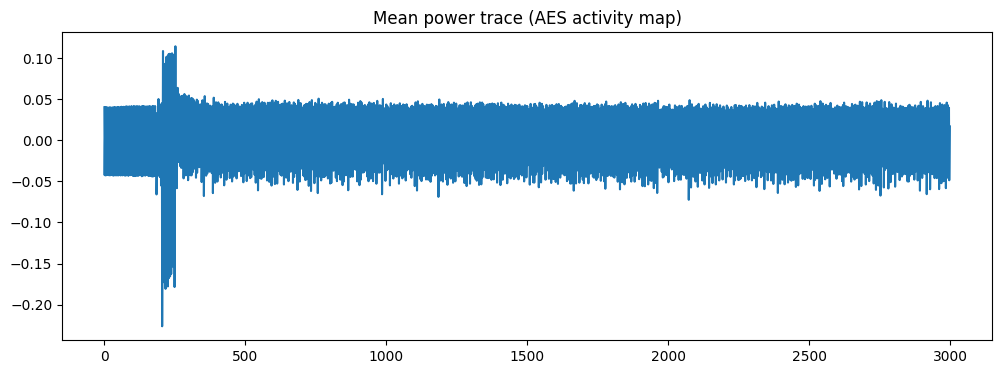

In [14]:
mean_trace = traces.mean(axis=0)

import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(mean_trace)
plt.title("Mean power trace (AES activity map)")
plt.show()


In [15]:
ALIGN_START = 400
ALIGN_END   = 1200

ref_seg = traces[0, ALIGN_START:ALIGN_END]

aligned = np.empty_like(traces)
shifts = np.zeros(traces.shape[0], dtype=int)

for i in range(traces.shape[0]):
    s, c = best_shift_by_corr(
        traces[i, ALIGN_START:ALIGN_END],
        ref_seg,
        max_shift=40
    )
    shifts[i] = s
    aligned[i] = apply_shift(traces[i], s)

aligned_traces = aligned

print("Shift stats:", shifts.min(), shifts.mean(), shifts.max())


Shift stats: 0 0.0 0


In [16]:
import chipwhisperer as cw
import numpy as np
import time

# Use your existing scope/target if already connected
# scope = cw.scope()
# target = cw.target(scope, cw.targets.CW305)

# fixed vectors (good for glitch scanning)
#KEY = bytes.fromhex("000102030405060708090a0b0c0d0e0f")
#PT  = bytes.fromhex("00112233445566778899aabbccddeeff")

KEY = bytes.fromhex("2b7e151628aed2a6abf7158809cf4f3c")
PT  = bytes.fromhex("5c692f9103b2302914d7e555e4dcee49")

target.fpga_write(target.REG_CRYPT_KEY, KEY)

# expected ciphertext
from Crypto.Cipher import AES
EXP_CT = AES.new(KEY, AES.MODE_ECB).encrypt(PT)
print("Expected:", EXP_CT.hex())


Expected: 06f36a65e8a99ff8907b2e5e5ddd77de


In [17]:
# --- Capture settings ---
#scope.default_setup()
# scope.gain.db = 35
# scope.adc.samples = 3000
# scope.adc.presamples = 200
# scope.adc.timeout = 2



scope.gain.gain = 40
scope.gain.mode = "high"
scope.adc.samples = 350
scope.adc.offset = 0
scope.adc.basic_mode = "rising_edge"
scope.clock.adc_src = "clkgen_x4"
scope.clock.freq_ctr_src = "clkgen"
scope.clock.adc_phase = 175
scope.trigger.triggers = "tio4"

# --- Clocking (typical CWLite setup) ---
# Keep these consistent with how you're currently clocking the CW305.
# If you already have stable traces, DON'T change clock settings drastically.
#scope.clock.clkgen_freq = 7.37e6     # common starting point; adjust if you use something else
# scope.clock.adc_src = "clkgen_x1"
# scope.clock.reset_adc()

#CLKGEN Settings
scope.clock.extclk_freq = 10000000
scope.clock.clkgen_mul = 5
scope.clock.clkgen_div = 48
scope.clock.clkgen_freq = 10000000

# --- Glitch routing ---
# For CWLite, these route the glitch module onto the clock line.
scope.io.glitch_lp = True
scope.io.glitch_hp = True

# --- Glitch parameters ---
scope.io.hs2 = "glitch"
scope.glitch.clk_src = 'clkgen'
scope.glitch.ext_offset = 0
#scope.glitch.width = 5.078125
#scope.glitch.offset = -1.953125
scope.glitch.trigger_src = "continuous" #"ext_single"  #change this depending on glitching desired   "ext_single"  "continuous"
scope.glitch.output = "clock_xor" 
scope.glitch.width = 10
scope.glitch.offset = -20
#self.api.setParameter(['Glitch Module', 'Output Mode', 'Clock XORd'])
scope.glitch.repeat = 5             # start with 1; increase later if needed

# scope.glitch.clk_src = 'clkgen'
# scope.glitch.ext_offset = 1
# scope.glitch.repeat = 2
# scope.glitch.width = 25.0
# scope.glitch.offset = 0
# scope.glitch.trigger_src = "ext_single"
# self.api.setParameter(['Glitch Module', 'Output Mode', 'Glitch Only'])
# self.api.setParameter(['CW Extra Settings', 'Target HS IO-Out', 'Glitch Module'])


# starting point (you will sweep these)
scope.glitch.width = 10
scope.glitch.offset = -20

print("Glitch ready.")

Glitch ready.


In [18]:
def aes_encrypt_once():
    # fire AES
    target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")
    # small wait so ciphertext register updates even if trigger missed
    time.sleep(0.001)
    return bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

def glitch_and_read():
    # arm scope + glitch
    scope.arm()

    # launch AES (this generates the external trigger used by ext_single)
    target.fpga_write(target.REG_CRYPT_TEXTIN, PT)
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")

    # capture waveform (optional but useful for debugging alignment)
    cap_timeout = scope.capture()
    ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

    if cap_timeout:
        return "no_trigger", ct, None

    tr = scope.get_last_trace()

    if ct == EXP_CT:
        return "correct", ct, tr
    else:
        return "faulty", ct, tr


In [19]:
for i in range(10):
    label, ct, tr = glitch_and_read()
    print(i, label, ct.hex())

0 correct 06f36a65e8a99ff8907b2e5e5ddd77de
1 correct 06f36a65e8a99ff8907b2e5e5ddd77de
2 correct 06f36a65e8a99ff8907b2e5e5ddd77de
3 correct 06f36a65e8a99ff8907b2e5e5ddd77de
4 correct 06f36a65e8a99ff8907b2e5e5ddd77de
5 correct 06f36a65e8a99ff8907b2e5e5ddd77de
6 correct 06f36a65e8a99ff8907b2e5e5ddd77de
7 correct 06f36a65e8a99ff8907b2e5e5ddd77de
8 correct 06f36a65e8a99ff8907b2e5e5ddd77de
9 correct 06f36a65e8a99ff8907b2e5e5ddd77de


In [21]:
faults = []   # store (width, offset, ciphertext_hex)
hits = {"correct":0, "faulty":0, "no_trigger":0}

widths  = range(-49, 49,2 )       # adjust range later
offsets = range(-49, 49,2)     # adjust range later

for w in widths:
    scope.glitch.width = w
    for off in offsets:
        scope.glitch.offset = off

        label, ct, tr = glitch_and_read()
        hits[label] += 1

        if label == "faulty":
            faults.append((w, off, ct.hex()))
            print("FAULT OCCURED HERE.. OHHH NOOOOOOOO", "w=", w, "off=", off, "ct=", ct.hex())
        # else:
        #     print("NORMAL", "w=", w, "off=", off, "ct=", ct.hex())

print("Summary:", hits)
print("Fault count:", len(faults))


FAULT OCCURED HERE.. OHHH NOOOOOOOO w= -25 off= 27 ct= ca381069e35f4c4b5cec3649105b93e9
FAULT OCCURED HERE.. OHHH NOOOOOOOO w= -1 off= 17 ct= 5328c410a2c7e715753d345ab6bc2d67
FAULT OCCURED HERE.. OHHH NOOOOOOOO w= -1 off= 27 ct= 5d15f00c94b9c11ed9399fdcdb708306
FAULT OCCURED HERE.. OHHH NOOOOOOOO w= -1 off= 47 ct= a9248b029f1627469d016cb0aa68e8dc
FAULT OCCURED HERE.. OHHH NOOOOOOOO w= 27 off= 23 ct= e19bb2fba333b5a2647e072cecd9e9ac
FAULT OCCURED HERE.. OHHH NOOOOOOOO w= 41 off= -39 ct= ed460aaff195ad7c92ede521452b7659
FAULT OCCURED HERE.. OHHH NOOOOOOOO w= 45 off= -43 ct= 4a25b75246a2f2aa4c8bc28a25bd24dd
FAULT OCCURED HERE.. OHHH NOOOOOOOO w= 47 off= -45 ct= 06f36a25e8a99fd9907b2e555ddd77de
Summary: {'correct': 2393, 'faulty': 8, 'no_trigger': 0}
Fault count: 8


In [22]:
import numpy as np
import time

#PT = bytes.fromhex("00112233445566778899aabbccddeeff")

def launch_aes(pt):
    target.fpga_write(target.REG_CRYPT_TEXTIN, pt)
    target.fpga_write(target.REG_CRYPT_GO, b"\x00")
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")

def glitch_capture_one(width, offset):
    # set glitch params
    scope.glitch.width = width
    scope.glitch.offset = offset

    # arm capture
    scope.arm()

    # run AES (this also triggers the glitch via ext_single)
    launch_aes(PT)

    # capture waveform
    timed_out = scope.capture()
    trace = None if timed_out else np.array(scope.get_last_trace(), dtype=np.float32)

    # read ciphertext regardless (sometimes still updates)
    ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

    if timed_out:
        label = "no_trigger"
    elif ct == EXP_CT:
        label = "correct"
    else:
        label = "faulty"

    return label, trace, ct

In [23]:
scope.adc.samples = 3000
scope.adc.presamples = 200
scope.gain.db = 35
scope.adc.timeout = 2
# Replace with a known fault point you found
CENTER_W = 47
CENTER_O = -45

w_list = range(CENTER_W -46, CENTER_W + 2, 1)
o_list = range(CENTER_O -4, CENTER_O + 94, 1)

N_PER_SETTING = 5  # repeat each setting to see stability


In [24]:
records = []  # list of dicts
traces = []
labels = []

for w in w_list:
    for o in o_list:
        for rep in range(N_PER_SETTING):
            label, trace, ct = glitch_capture_one(w, o)

            records.append({
                "width": w,
                "offset": o,
                "rep": rep,
                "label": label,
                "ct_hex": ct.hex(),
            })

            # store traces only if we actually captured a trace
            if trace is not None:
                traces.append(trace)
                labels.append(label)

            if label == "faulty":
                print("FAULT", "w", w, "off", o, "ct", ct.hex())

print("Total attempts:", len(records))
print("Captured traces:", len(traces))
print("Faults:", sum(r["label"]=="faulty" for r in records))


(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfigu

FAULT w 1 off 6 ct ca381069e35f4c4b5cec3649105b93e9
FAULT w 1 off 29 ct 943479035e98e33eef461dc8244aaffe
FAULT w 2 off -38 ct fdc3f9c6ea54ad15815347f28646ccf8
FAULT w 2 off -3 ct 2df5599adca7255e8509c4e2f639e490
FAULT w 2 off -3 ct 06f36a65e8a997f8907b2e5e5ddd77de


(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfigu

FAULT w 2 off 5 ct 84e183c6908ceb57fa9f7ffda56b0bc5
FAULT w 2 off 12 ct 3b49e181394ac3bf9fa15b5177bacb00
FAULT w 2 off 16 ct 1ef36a25b8a99fd990286cf75dddcfde
FAULT w 2 off 16 ct 06f36a65e8a99ff8907b2e5e4ddd77de
FAULT w 2 off 28 ct e7d6bc6acda95ca094ea376d1beb7830
FAULT w 2 off 30 ct 582288c094fa0559c25382f4de61193b
FAULT w 2 off 31 ct 9f565e8b1d4f9170ebdc2eca7017d788
FAULT w 2 off 31 ct 87177eb4a9000ceb5be36c0fdc0ce7ce
FAULT w 2 off 33 ct c062ca082e523472123741996da0a364
FAULT w 2 off 33 ct f0f0924d9e033a9b98643dd9eeed544a


(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfigu

...

FAULT w 47 off 3 ct 523d8e1cea9c90b3edff1d5aaa15383c
FAULT w 48 off -49 ct 7f5f8c493e375a150af6123b604282c7
FAULT w 48 off -49 ct 3894ea2f1d0d9ef34007a5d0173db494
FAULT w 48 off -49 ct 616014ac89dea3e06a84ccccf846e2b4


(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0b
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no trigger seen! Trigger forced, data is invalid. Status: 0a
(ChipWhisperer Scope WARNING|File _OpenADCInterface.py:732) Timeout in OpenADC capture(), no t

FAULT w 48 off -46 ct 7259e550b3d85ccdd34d91cd46ea0f37


(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfiguration for offset = 0 may not work
(ChipWhisperer Glitch WARNING|File ChipWhispererGlitch.py:793) Partial reconfigu

FAULT w 48 off 2 ct 053eb22847979c313593de24ef805e72
Total attempts: 23520
Captured traces: 23515
Faults: 39


In [25]:
import numpy as np
import json

traces_np = np.vstack(traces)  # (num_captured, samples)

np.savez(
    "cw305_glitch_traces1.npz",
    traces=traces_np,
    labels=np.array(labels, dtype="U10"),
    records_json=np.array([json.dumps(r) for r in records], dtype=object),
)

print("Saved: cw305_glitch_traces.npz")


Saved: cw305_glitch_traces.npz


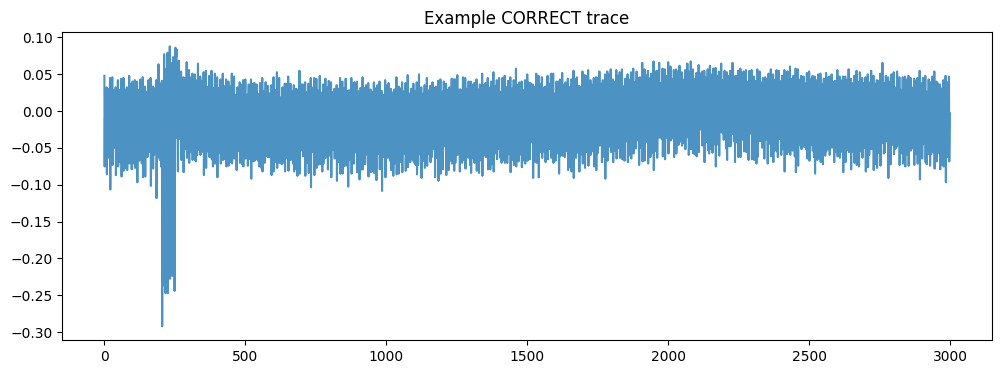

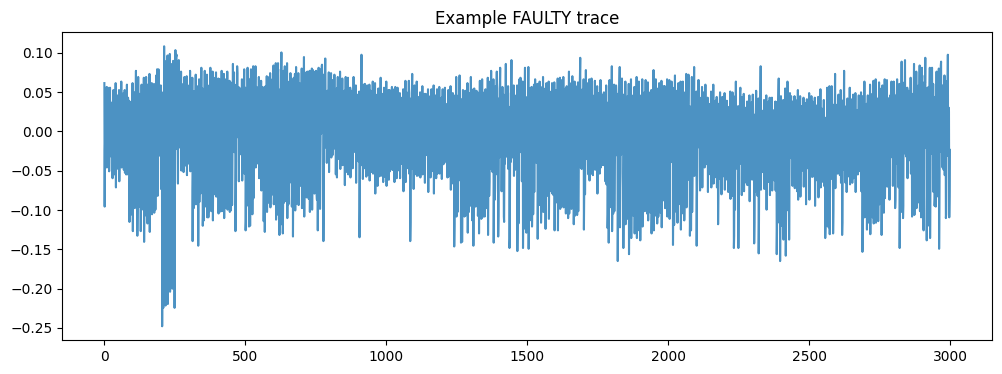

In [26]:
import matplotlib.pyplot as plt
import numpy as np

tr = traces_np
lab = np.array(labels)

fault_idx = np.where(lab == "faulty")[0]
corr_idx  = np.where(lab == "correct")[0]

plt.figure(figsize=(12,4))
if len(corr_idx) > 0:
    plt.plot(tr[corr_idx[0]], alpha=0.8)
    plt.title("Example CORRECT trace")
    plt.show()

plt.figure(figsize=(12,4))
if len(fault_idx) > 0:
    plt.plot(tr[fault_idx[0]], alpha=0.8)
    plt.title("Example FAULTY trace")
    plt.show()


In [24]:
print(scope.clock)

adc_src       = clkgen_x1
adc_phase     = 0
adc_freq      = 7384620
adc_rate      = 7384620.0
adc_locked    = True
freq_ctr      = 10000396
freq_ctr_src  = extclk
clkgen_src    = system
extclk_freq   = 10000000
clkgen_mul    = 2
clkgen_div    = 26
clkgen_freq   = 7384615.384615385
clkgen_locked = True



In [29]:
print([x for x in dir(scope.glitch) if "output" in x or "clk" in x or "repeat" in x])
print("glitch output =", scope.glitch.output)


['_output_modes', 'clk_src', 'output', 'repeat']
glitch output = clock_xor


In [28]:
import time
import numpy as np

#PT = bytes.fromhex("00112233445566778899aabbccddeeff")

def launch_aes(pt):
    target.fpga_write(target.REG_CRYPT_TEXTIN, pt)    target.fpga_write(target.REG_CRYPT_GO, b"\x00")
    target.fpga_write(target.REG_CRYPT_GO, b"\x01")

def glitch_once():
    scope.arm()
    launch_aes(PT)

    timed_out = scope.capture()
    ct = bytes(target.fpga_read(target.REG_CRYPT_CIPHEROUT, 16))

    if timed_out:
        return "no_trigger", ct
    elif ct == EXP_CT:
        return "correct", ct
    else:
        return "faulty", ct

# --- Glitch settings (stronger) ---
scope.io.glitch_lp = True
scope.io.glitch_hp = True
scope.glitch.clk_src = "clkgen"
scope.glitch.trigger_src = "ext_single"
scope.glitch.repeat = 10

# choose output mode
try:
    scope.glitch.output = "clock_or"
except Exception:
    scope.glitch.output = "clock_xor"

widths  = range(1, 49, 2)
offsets = range(-49, 49, 2)
tries_per_point = 10

hits = {"correct":0, "faulty":0, "no_trigger":0}
faults = []

for w in widths:
    scope.glitch.width = w
    for off in offsets:
        scope.glitch.offset = off

        for _ in range(tries_per_point):
            label, ct = glitch_once()
            hits[label] += 1

            if label == "faulty":
                faults.append((w, off, ct.hex()))
                print("FAULT  w=", w, "off=", off, "ct=", ct.hex())
                break  # found a fault at this setting; move on

print("Summary:", hits)
print("Fault count:", len(faults))


Summary: {'correct': 11760, 'faulty': 0, 'no_trigger': 0}
Fault count: 0
